In [1]:
# Market Analysis: Gold, Silver and Macroeconomic Factors

In [2]:
## 1. Objective
### To analyze the relation between gold and silver returns, with macroeconomic proxies such as CPI, FONC, and NFP. This study aims to determine whether these macroeconomic factors have an influence over commodity prices using
### statistical and time-series analysis techniques. The looks at whether there is a significant linear relationship
### between economic indicators and commodity returns.
### The analysis also seeks to evaluate how effective linear regression models are in capturing financial dynamics.

In [3]:
## 2. Data Sources and Variables

## This study utilises time-series data for commodity prices, financial market indices, and macroeconomic indicators to analyse their relationship with gold and silver returns.
## Gold (XAU) and silver (XAG) prices are used to compute returns, which serve as the primary dependent variables in the analysis. Returns are calculated to capture relative price changes over time and to stabilise the data for statistical modelling.
## In addition to macroeconomic variables, key financial market indicators are included to better capture broader market dynamics:

## - **CPI (Consumer Price Index):** Proxy for inflation.
## - **FOMC:** Represents monetary policy signals and interest rate decisions.
## - **NFP (Non-Farm Payrolls):** Indicator of labour market strength and economic activity.
## - **DXY (US Dollar Index):** Measures the strength of the US dollar, which has an inverse relationship with gold prices.
## - **S&P 500:** Represents equity market performance and overall investor sentiment.
## - **USOIL:** Proxy for energy prices and global economic activity.

## These variables are selected to capture multiple dimensions of market behaviour, including inflation, monetary policy, currency strength, and risk sentiment. Due to differences in data frequency (e.g., daily financial data versus monthly macroeconomic indicators), the datasets are aligned and transformed where necessary. This includes converting date formats, handling missing values, and ensuring consistent time intervals across all variables.
## The final dataset consists of cleaned and aligned observations suitable for time-series analysis and regression modelling.

In [4]:
# 1. Market data
import yfinance as yf

gold = yf.download("GC=F", start="2000-01-01", end="2026-03-19")
silver = yf.download("SI=F", start="2000-01-01", end="2026-03-19")
DXY = yf.download("DX-Y.NYB", start="2000-01-01", end="2026-03-19")
oil = yf.download("CL=F", start="2000-01-01", end="2026-03-19")
sp500 = yf.download("^GSPC", start="2000-01-01", end="2026-03-19")

# 2. Macro-data (FRED - Federeal Reserve Economic Data)
from pandas_datareader import data as pdr

CPI = pdr.DataReader("CPIAUCSL", "fred", start="2000-01-01", end="2026-03-19") # Consumer Price Index: measures infaltion
CPI = CPI.dropna()
FOMC = pdr.DataReader("FEDFUNDS", "fred", start="2000-01-01", end="2026-03-19") # Federal Open Market Committe: interest rates
FOMC = FOMC.dropna()
NFP = pdr.DataReader("PAYEMS", "fred", start="2000-01-01", end="2026-03-19") # Non-Farm Payrolls: employment
NFP = NFP.dropna()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
## 3. Data Cleaning and Preparation

#The raw datasets required several preprocessing steps to ensure consistency and suitability for time-series analysis and regression modelling.

### Data Formatting
#All date variables were converted into a standard datetime format to allow proper time alignment across datasets. The data was then sorted chronologically to maintain the correct temporal order.

### Handling Missing and Invalid Values
#Missing values (NaN) and infinite values (inf, -inf) were identified and handled appropriately. These values were either replaced or removed to prevent errors during statistical modelling.

#Rows containing missing values across key variables were dropped to ensure that the regression model was estimated using complete observations only.

### Conversion to Numeric Types
#Some variables were initially stored as strings or contained non-numeric characters. These were cleaned and converted into numeric format to allow for proper statistical analysis.

### Return Calculation
#Gold (XAU) and silver (XAG) prices were transformed into returns using percentage change. This transformation was applied to stabilise the data and focus on relative price movements rather than absolute values.

### Time Alignment
#Due to differences in data frequency (e.g., daily financial data versus monthly macroeconomic data), the datasets were aligned to a consistent time frame. This ensured that each observation corresponded correctly across all variables.

### Feature Preparation
#Independent variables (CPI, FOMC, NFP, DXY, S&P 500, and USOIL) were prepared for regression analysis. Categorical variables such as FOMC were encoded into numerical form where necessary.

#A constant term was added to the regression model to account for the intercept.

#The final cleaned dataset was then used for exploratory analysis and regression modelling.

In [7]:
#### Prep Data and convert to returns
import numpy as np

gold = gold[['Close']]
gold['return'] = np.log(gold['Close']/gold['Close'].shift(1))

silver = silver[['Close']]
silver['return'] = np.log(silver['Close']/silver['Close'].shift(1))

DXY = DXY[['Close']]
DXY['return'] = np.log(DXY['Close']/DXY['Close'].shift(1))

oil = oil[['Close']]
oil['return'] = np.log(oil['Close']/oil['Close'].shift(1))

sp500 = sp500[['Close']]
sp500['return'] = np.log(sp500['Close']/sp500['Close'].shift(1))

/home/user/miniconda3/envs/py39/lib/python3.9/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


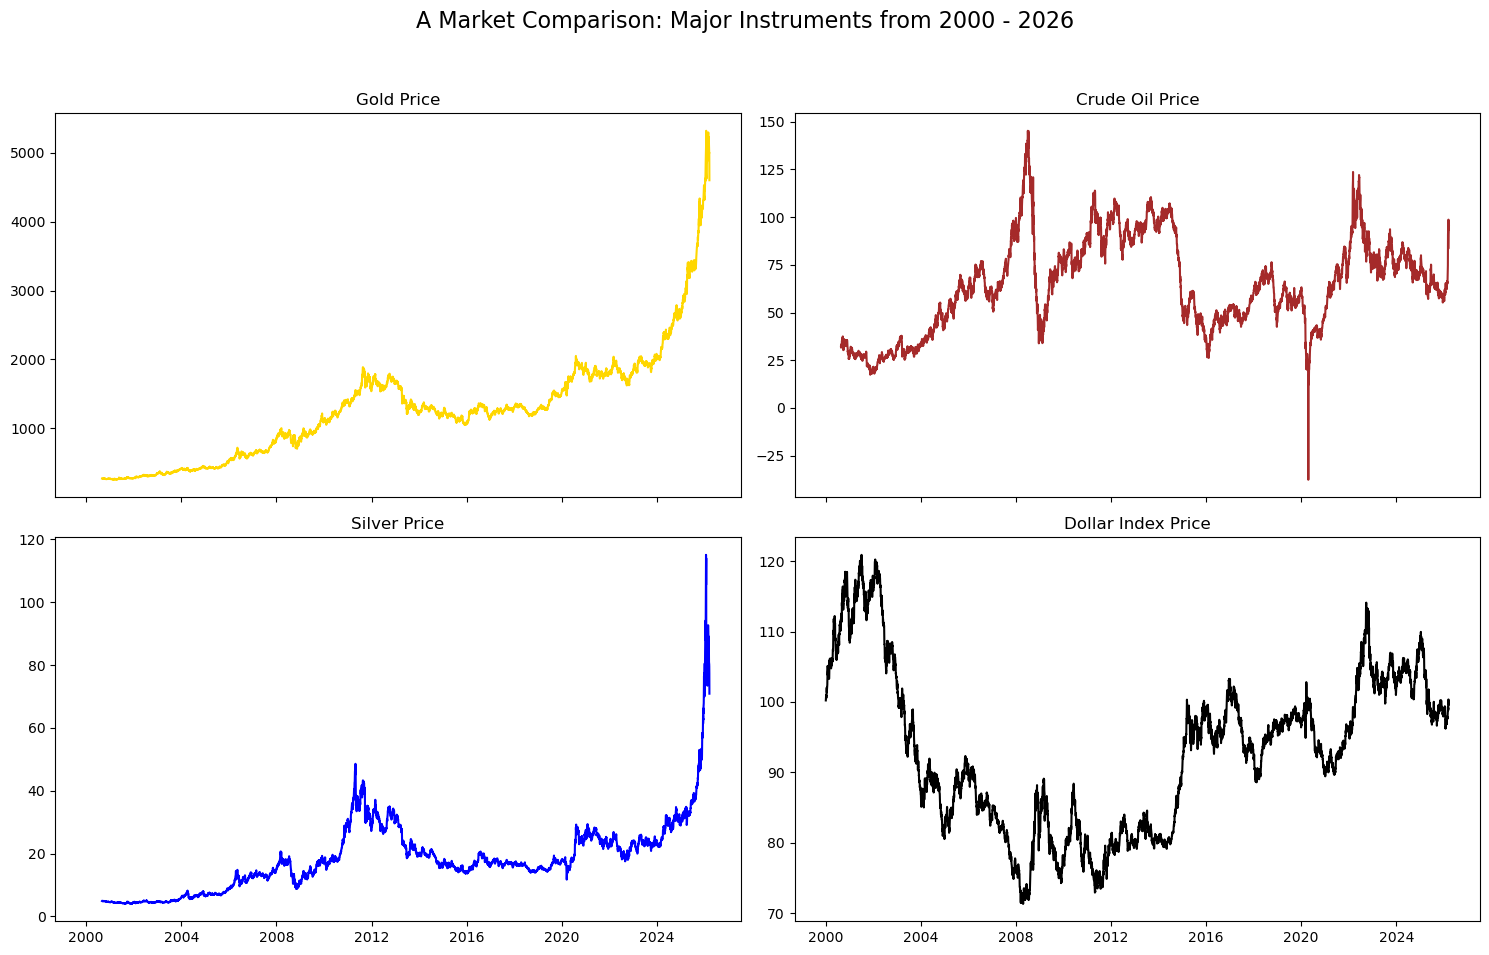

In [80]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True)

# --- TOP LEFT: Gold ---
axs[0, 0].plot(gold.index, gold[['Close']], color='gold')
axs[0, 0].set_title('Gold Price')

# --- TOP RIGHT: USOIL ---
axs[0, 1].plot(oil.index, oil[['Close']], color='brown')
axs[0, 1].set_title('Crude Oil Price')

# --- BOTTOM LEFT: Silver ---
axs[1, 0].plot(silver.index, silver[['Close']], color='blue', label='XAG')
axs[1, 0].set_title('Silver Price')

# --- BOTTOM RIGHT: Dollar Index ---
axs[1, 1].plot(DXY.index, DXY[['Close']], color='black', label='DXY')
axs[1, 1].set_title('Dollar Index Price')

# 2. Add a main title for the whole window
fig.suptitle('A Market Comparison: Major Instruments from 2000 - 2026', fontsize=16)

# 3. Fix layout so titles don't hit the axis labels
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()


In [8]:
#### Convert Macro data to % Change and resample to daily to match the market data
CPI['cpi_change'] = CPI.pct_change()
CPI = CPI.resample('D').ffill()
FOMC['fomc_change'] = FOMC.pct_change()
FOMC = FOMC.resample('D').ffill()
NFP['nfp_change'] = NFP.pct_change()
NFP = NFP.resample('D').ffill()

In [10]:
#### Merge Macro and Market data
import pandas as pd

full_data = pd.concat([gold['return'], silver['return'], DXY['return'], oil['return'], sp500['return'],
                      CPI['cpi_change'], FOMC['fomc_change'], NFP['nfp_change']], axis=1)
full_data.columns = ['gold_return', 'silver_return', 'DXY_return', 'oil_return', 'sp500_return',
                    'cpi', 'fomc', 'nfp']
####full_data = full_data.dropna()

In [11]:
# 4. Exploratory Data Analysis
## This section explores the behaviour of key variables and their relationships to understand underlying patterns before modelling.

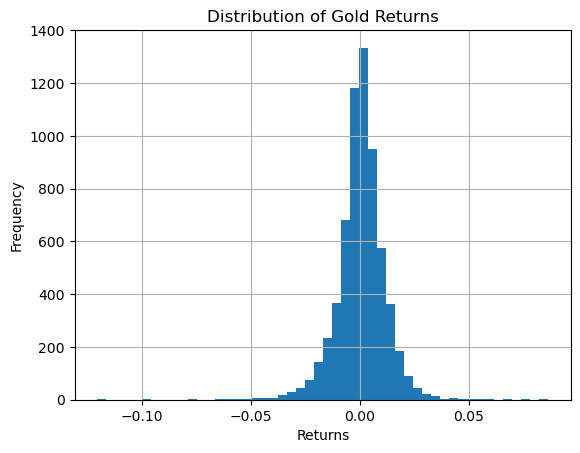

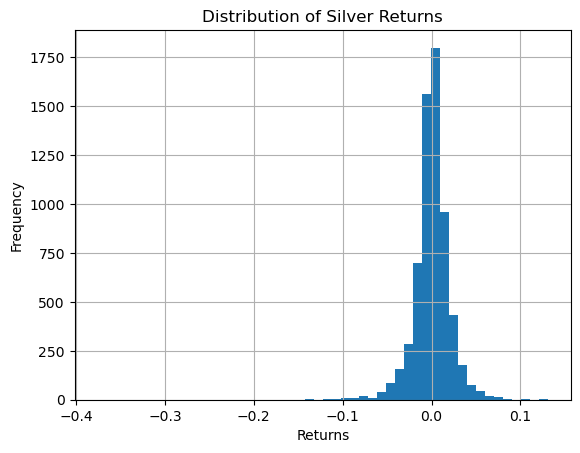

In [15]:
### 4.1 Distribution of Gold and Silver Returns
#### Understanding the distribution of returns helps identify volatility, skewness, and extreme values in the data.

import matplotlib.pyplot as plt

full_data['gold_return'].hist(bins=50)
plt.title('Distribution of Gold Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()

full_data['silver_return'].hist(bins=50)
plt.title('Distribution of Silver Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()

In [16]:
#### Gold and silver returns exhibit high variability and potential skewness, which is typical for financial time-series data. The presence of extreme values suggests periods of high market volatility.

In [26]:
### 4.2 Time Series Behaviour
#### Plotting the returns over time helps identify trends, spikes, and volatility clustering.

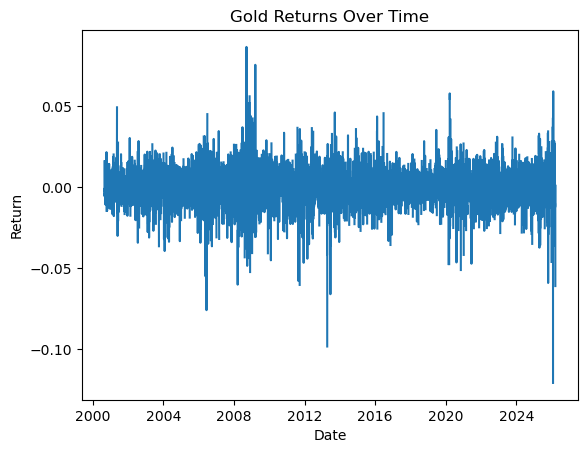

In [27]:
plt.plot(full_data.index, full_data['gold_return'])
plt.title('Gold Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Return')
plt.show()

In [28]:
### 4.3 Relationship with Market Indicators

#### Scatter plots are used to explore potential relationships between gold returns and key variables such as DXY and S&P 500.

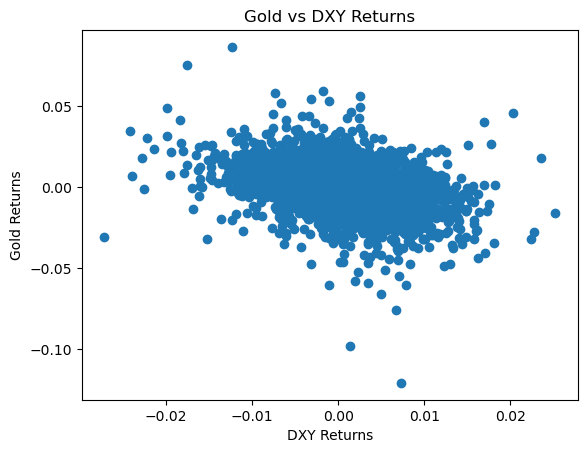

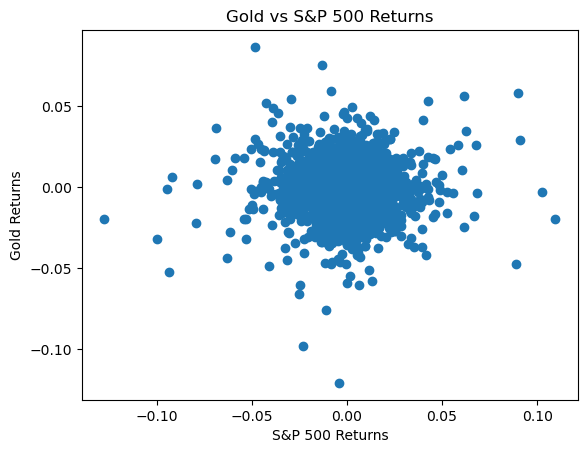

In [32]:
plt.scatter(full_data['DXY_return'], full_data['gold_return'])
plt.title('Gold vs DXY Returns')
plt.xlabel('DXY Returns')
plt.ylabel('Gold Returns')
plt.show()

plt.scatter(full_data['sp500_return'], full_data['gold_return'])
plt.title('Gold vs S&P 500 Returns')
plt.xlabel('S&P 500 Returns')
plt.ylabel('Gold Returns')
plt.show()

In [33]:
#### The relationship between gold returns and DXY appears weak, with no strong linear pattern. Similarly, the relationship with the S&P 500 does not show a clear directional trend, suggesting that these relationships may be non-linear or influenced by other factors.

In [34]:
### 4.4 Correlation Analysis
#### A correlation matrix is used to quantify linear relationships between variables.

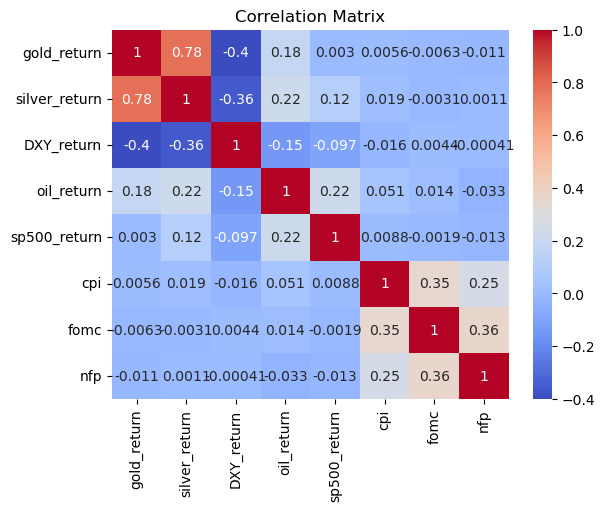

In [36]:
import seaborn as sns

corr = full_data[['gold_return', 'silver_return', 'DXY_return', 'oil_return', 'sp500_return',
                    'cpi', 'fomc', 'nfp']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [38]:
#### The correlation matrix indicates generally weak linear relationships between gold returns and macroeconomic variables.
#### This suggests that gold price movements may be influenced by complex, non-linear dynamics rather than simple linear relationships.

In [39]:
### 4.5 Volatility Observation
#### Rolling statistics are used to observe changes in volatility over time.

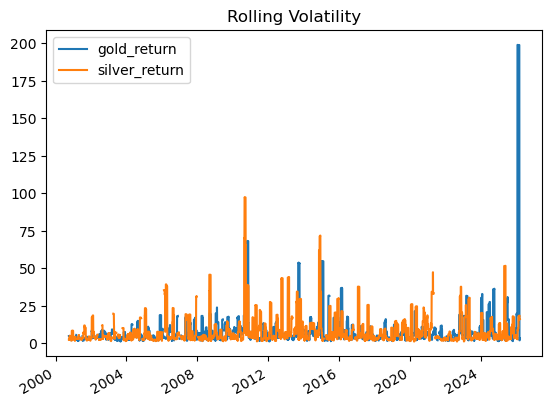

In [52]:
full_data['gold_return'].pct_change().rolling(window=30).std().plot()
full_data['silver_return'].pct_change().rolling(window=30).std().plot()
plt.title('Rolling Volatility')
plt.legend()
plt.show()

In [63]:
#### We also were able to demostate the market price of Crude oil, Gold and the dollar index in times of crises
#### the beginning of the period: 

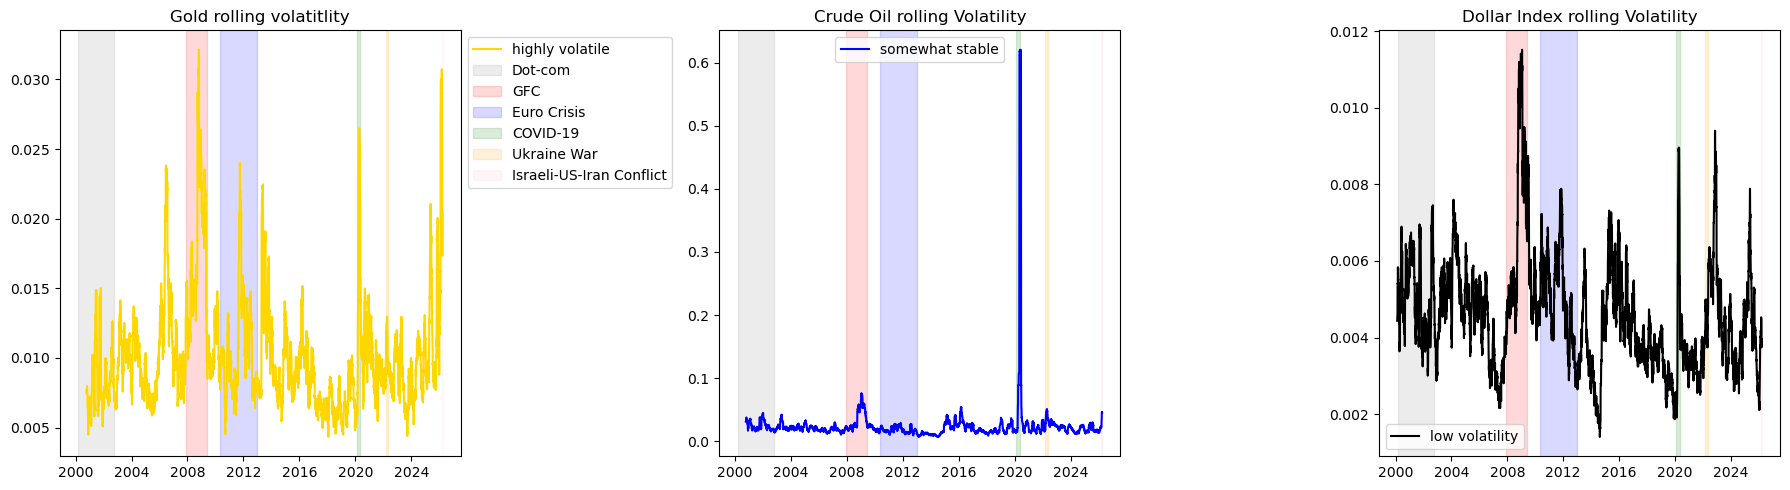

In [66]:
gold_rol_volatility = gold['Close'].pct_change().rolling(window=30).std() #30 day window
oil_rol_volatility = oil['Close'].pct_change().rolling(window=30).std()
dxy_rol_volatility = DXY['Close'].pct_change().rolling(window=30).std()

def add_crisis_shading(ax):
    """Adds shaded regions for major economic crises to a given axis."""
    crises = [
        ("Dot-com", "2000-03-01", "2002-10-01", "gray"),
        ("GFC", "2007-12-01", "2009-06-01", "red"),
        ("Euro Crisis", "2010-05-01", "2012-12-31", "blue"),
        ("COVID-19", "2020-02-01", "2020-04-30", "green"),
        ("Ukraine War", "2022-02-24", "2022-04-30", "orange"),
        ("Israeli-US-Iran Conflict", "2026-02-28", "2026-03-16", "pink")
    ]
    
    for name, start, end, color in crises:
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), 
                   color=color, alpha=0.15, label=name)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(gold_rol_volatility, color='gold', label='highly volatile')
ax1.set_title('Gold rolling volatitlity')
ax1.legend()

ax2.plot(oil_rol_volatility, color='blue', label='somewhat stable')
ax2.set_title('Crude Oil rolling Volatility')
ax2.legend()

ax3.plot(dxy_rol_volatility, color='black', label='low volatility')
ax3.set_title('Dollar Index rolling Volatility')
ax3.legend()

for ax in [ax1, ax2, ax3]:
    add_crisis_shading(ax)

# Only show the legend once to keep it clean
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [53]:
#### Volatility is not constant and shows clustering behaviour, where periods of high volatility are followed by similar periods. 

In [54]:
## 5. Regression Analysis
#### This section applies an Ordinary Least Squares (OLS) regression model to evaluate the relationship between gold and silver returns and selected macroeconomic and market variables.

In [55]:
### 5.1 Model Specification

#### The regression model is specified as follows:

#### Gold Return = β₀ + β₁(CPI) + β₂(DXY) + β₃(S&P 500) + β₄(USOIL) + β₅(NFP) + ε

#### where:
#### - Gold Return is the dependent variable
#### - CPI, DXY, S&P 500, USOIL, and NFP are independent variables
#### - ε represents the error term

In [58]:
import numpy as np
import statsmodels.api as sm

#select the variables
model_data = full_data[['gold_return','DXY_return', 'oil_return', 'sp500_return',
                    'cpi', 'fomc', 'nfp']]
# Clean properly
# All variables were cleaned to remove missing and infinite values before fitting the regression model.
#Only complete observations were used to ensure valid estimation.
model_data = model_data.replace([np.inf, -np.inf], np.nan)
model_data = model_data.dropna()

# Define X and y
X = model_data[['DXY_return', 'oil_return', 'sp500_return',
                    'cpi', 'fomc', 'nfp']]
y = model_data['gold_return']

# Add constant
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                  0.181
Method:                 Least Squares   F-statistic:                     235.2
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          2.67e-272
Time:                        06:33:03   Log-Likelihood:                 20285.
No. Observations:                6369   AIC:                        -4.056e+04
Df Residuals:                    6362   BIC:                        -4.051e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0005      0.000      2.981   

In [70]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

#choose your predictor(s)
X = full_data[['DXY_return', 'oil_return', 'sp500_return', 'cpi', 'fomc', 'nfp']].copy()
y = full_data['silver_return'].copy()

# Convert everything to numeric
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

# Combine using matching index
model_data = pd.concat([X, y], axis=1)

print("Before dropna:", model_data.shape)
print(model_data.isna().sum())

model_data = model_data.dropna()

print("After dropna:", model_data.shape)
print(model_data.head())

# Stop early if empty
if model_data.empty:
    raise ValueError("No valid rows left after cleaning. Check X, y, and index alignment.")

X_clean = model_data[X.columns]
y_clean = model_data['silver_return']

X_clean = sm.add_constant(X_clean)

silver_model = sm.OLS(y_clean, X_clean).fit()
print(silver_model.summary())

Before dropna: (9562, 7)
DXY_return       2943
oil_return       3145
sp500_return     2972
cpi                64
fomc               64
nfp                64
silver_return    3150
dtype: int64
After dropna: (6370, 7)
            DXY_return  oil_return  sp500_return       cpi      fomc  \
2000-08-31    0.004094   -0.009023      0.009993  0.000000 -0.006116   
2000-09-01   -0.010535    0.008424      0.002034  0.005211  0.003077   
2000-09-05    0.008846    0.012504     -0.009043  0.005211  0.003077   
2000-09-06    0.015098    0.033458     -0.009889  0.005211  0.003077   
2000-09-07   -0.004127    0.010814      0.006852  0.005211  0.003077   

                 nfp  silver_return  
2000-08-31  0.000045       0.014699  
2000-09-01  0.000779       0.000200  
2000-09-05  0.000779      -0.001200  
2000-09-06  0.000779      -0.003006  
2000-09-07  0.000779      -0.009679  
                            OLS Regression Results                            
Dep. Variable:          silver_return   R-sq

In [59]:
### 5.3 Regression Results

#### The regression results indicate that the selected macroeconomic and market variables do not exhibit
#### strong statistically significant relationships with gold returns at conventional significance levels.

#### The R-squared value is relatively low, suggesting that the model explains only a small portion of the variation in gold returns.

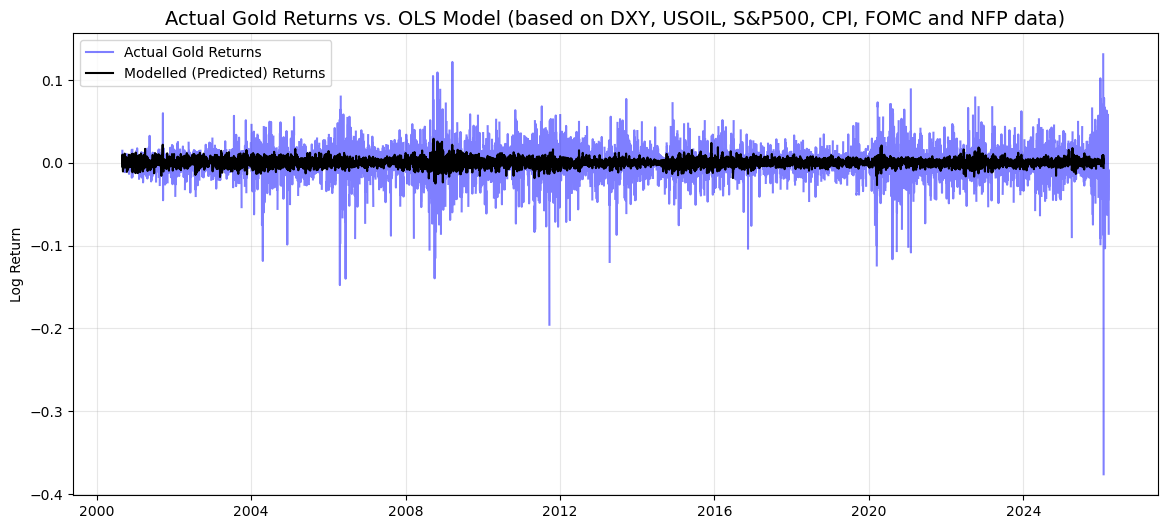

In [73]:
# 1. Get the predictions (modelled returns)
# Note: fittedvalues only exists for the rows used in the model
gold_modelled = model.fittedvalues

# 2. Plot Actual vs Modelled
plt.figure(figsize=(14, 6))

# Plot Actual (The 'y' you used in the model)
plt.plot(y.index, y.values, 
         label='Actual Gold Returns', color='blue', alpha=0.5)

# Plot Modelled (The 'fitted values')
plt.plot(gold_modelled.index, gold_modelled.values, 
         label='Modelled (Predicted) Returns', color='black', linewidth=1.5)

# 3. Styling
plt.title('Actual Gold Returns vs. OLS Model (based on DXY, USOIL, S&P500, CPI, FOMC and NFP data)', fontsize=14)
plt.ylabel('Log Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

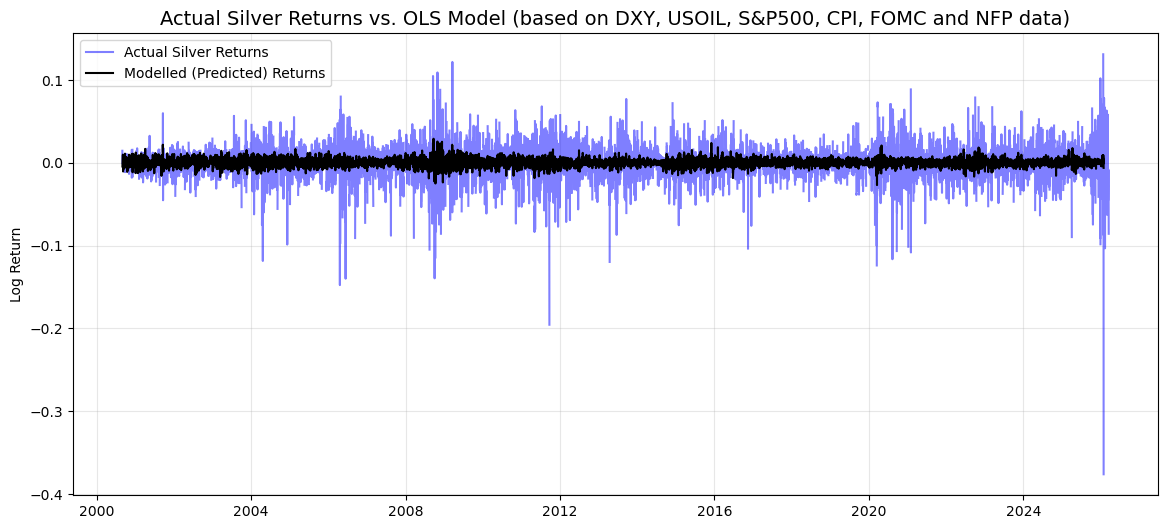

In [76]:
# 1. Get the predictions (modelled returns)
# Note: fittedvalues only exists for the rows used in the model
silver_modelled = silver_model.fittedvalues

# 2. Plot Actual vs Modelled
plt.figure(figsize=(14, 6))

# Plot Actual (The 'y' you used in the model)
plt.plot(y.index, y.values, 
         label='Actual Silver Returns', color='blue', alpha=0.5)

# Plot Modelled (The 'fitted values')
plt.plot(silver_modelled.index[1:], gold_modelled.values, 
         label='Modelled (Predicted) Returns', color='black', linewidth=1.5)

# 3. Styling
plt.title('Actual Silver Returns vs. OLS Model (based on DXY, USOIL, S&P500, CPI, FOMC and NFP data)', fontsize=14)
plt.ylabel('Log Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [60]:
### This does not necessarily imply that no relationship exists. Instead, it suggests that:

#### - The relationships may be non-linear
#### - The effects of macroeconomic variables may be lagged rather than immediate
#### - Financial markets are influenced by multiple interacting factors beyond those included in the model
#### - Gold may react more strongly to expectations rather than realised macroeconomic data

In [61]:
### 5.4 Economic Interpretation
#### Gold and silver are often considered hedge against uncertainty, inflation, and currency fluctuations. However, the weak relationships observed in this analysis suggest that gold price movements may be driven more by market sentiment, expectations, and global risk conditions rather than direct linear relationships with macroeconomic indicators.

#### The inclusion of variables such as DXY and S&P 500 aimed to capture broader market dynamics, yet their limited explanatory power further supports the complexity of financial markets.

In [62]:
### 5.5 Limitations
#### The model has several limitations:

#### - Differences in data frequency (daily vs monthly)
#### - Potential omission of relevant variables (e.g., interest rates, geopolitical risk)
#### - Lack of lagged variables
#### - Assumption of linear relationships

#### Future analysis could incorporate non-linear models, lag structures, or machine learning approaches to better capture these dynamics.

In [81]:
## 6. Conclusion

### This study examined the relationship between gold and silver returns and a set of macroeconomic and financial market variables, including CPI, NFP, FOMC, DXY, S&P 500, and USOIL.

### The analysis showed that there are generally weak linear relationships between gold returns and the selected variables. While traditional theory suggests that gold should respond to factors such as inflation and currency strength, the regression results indicate that these relationships are not strongly captured using a simple linear model.

### This highlights the complexity of financial markets. Gold price movements appear to be influenced not only by observed macroeconomic indicators, but also by expectations, market sentiment, and global uncertainty. Additionally, the timing of macroeconomic effects may not be immediate, suggesting that lagged relationships could be more relevant.

### Future work could improve the model by incorporating lagged variables, higher-frequency data, additional financial indicators, or non-linear modelling techniques. Machine learning approaches may also offer improved predictive performance by capturing more complex relationships.

### Overall, this project demonstrates a structured approach to financial data analysis, combining data cleaning, visualization, and statistical modelling to investigate real-world market behaviour.

SyntaxError: invalid syntax (4171646862.py, line 3)